In [1]:
import os
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.cm as cm


In [2]:
df_co2 = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed_v1.1\emissions.csv').dropna(subset=['income_group'])
df_dash = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed_v1.1\dash.csv').dropna(subset=['income_group'])
df_phdi = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed_v1.1\phdi.csv').dropna(subset=['income_group'])
df_medit = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed_v1.1\medit.csv').dropna(subset=['income_group'])

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from typing import List, Dict, Tuple, Optional
from scipy import stats

# -------------------------------------------------------------------------
# Helper functions (unchanged from original except minor adjustments)
# -------------------------------------------------------------------------

def _process_diet_data(df: pd.DataFrame, n_years: int = 7) -> pd.DataFrame:
    try:
        data_cols = df.columns[1:1 + n_years]
        cols_as_int = data_cols.astype(int)
    except Exception:
        data_cols = [c for c in df.columns if str(c).isdigit()][:n_years]
    
    if len(data_cols) == 0:
        return pd.DataFrame()

    mean = df[data_cols].mean(axis=0, numeric_only=True)
    std = df[data_cols].std(axis=0, ddof=1, numeric_only=True)
    n = df[data_cols].count(axis=0)
    
    se = std / np.sqrt(n.replace(0, np.nan))
    ci_lo = mean - 1.96 * se
    ci_hi = mean + 1.96 * se

    out_df = pd.DataFrame({
        "year": data_cols.astype(int),
        "mean": mean.values,
        "ci_lo": ci_lo.values,
        "ci_hi": ci_hi.values,
    })
    
    out_df["ci_lo"] = out_df["ci_lo"].fillna(out_df["mean"])
    out_df["ci_hi"] = out_df["ci_hi"].fillna(out_df["mean"])
    
    return out_df


def _process_co2_data(df: pd.DataFrame, n_rows: int = 7) -> pd.DataFrame:
    if "year" not in df.columns or "emissions" not in df.columns:
        raise ValueError("CO2 DataFrame must contain 'year' and 'emissions' columns")

    grp = df.groupby("year")["emissions"]
    years = sorted(grp.groups.keys())
    
    rows = []
    target_years = years[:n_rows] if n_rows else years

    for y in target_years:
        s = grp.get_group(y).dropna()
        n = len(s)
        m = s.mean()
        
        if n > 1:
            sd = s.std(ddof=1)
            se = sd / np.sqrt(n)
            ci_half = 1.96 * se
        else:
            ci_half = 0

        rows.append({
            "year": int(y),
            "mean": m,
            "ci_lo": m - ci_half,
            "ci_hi": m + ci_half,
        })
    
    return pd.DataFrame(rows)


def _annotate_grouped(
    ax: plt.Axes,
    entries: List[Dict],
    start_up: int = 10,
    start_down: int = -10
):
    groups: Dict[int, List[Dict]] = {}
    for e in entries:
        groups.setdefault(int(e["year"]), []).append(e)

    for year, items in groups.items():
        items_sorted = sorted(items, key=lambda x: x["value"], reverse=True)
        mid = (len(items_sorted) + 1) // 2
        above_items = items_sorted[:mid]
        below_items = items_sorted[mid:]

        for i, it in enumerate(above_items, start=1):
            ax.annotate(
                it["text"],
                (it["year"], it["value"]),
                textcoords="offset points",
                xytext=(0, start_up + (i * 2)),
                ha="center",
                fontsize=8,
                color=it["color"],
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.1", edgecolor=it["color"], facecolor="white", alpha=0.8)
            )

        for i, it in enumerate(below_items, start=1):
            ax.annotate(
                it["text"],
                (it["year"], it["value"]),
                textcoords="offset points",
                xytext=(0, start_down - (i * 2)),
                ha="center",
                fontsize=8,
                color=it["color"],
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.1", edgecolor=it["color"], facecolor="white", alpha=0.8)
            )


# -------------------------------------------------------------------------
# Desired order for income groups
# -------------------------------------------------------------------------
INCOME_ORDER = ["High income", "Middle income", "Low income"]


def _order_income_groups(groups: set) -> List[str]:
    groups = [g for g in groups if pd.notna(g)]
    ordered = [g for g in INCOME_ORDER if g in groups]
    rest = sorted([g for g in groups if g not in INCOME_ORDER], key=lambda x: str(x))
    return ordered + rest


# -------------------------------------------------------------------------
# Statistical test helper
# -------------------------------------------------------------------------
def _compare_groups(groups_data: List[np.ndarray]) -> Optional[float]:
    """
    Perform one-way ANOVA to compare means across groups.
    If ANOVA cannot be computed (e.g., zero variance, <2 obs), fall back to
    Kruskal-Wallis. Return p-value or None if test impossible.
    """
    # Remove empty groups
    valid = [g for g in groups_data if len(g) > 0]
    if len(valid) < 2:
        return None

    # Check if all groups have at least 2 observations and non-zero variance
    can_anova = all(len(g) >= 2 and np.var(g) > 0 for g in valid)
    if can_anova:
        try:
            _, p = stats.f_oneway(*valid)
            return p
        except Exception:
            pass

    # Fallback: Kruskal-Wallis (requires at least 2 groups)
    try:
        _, p = stats.kruskal(*valid)
        return p
    except Exception:
        return None


# -------------------------------------------------------------------------
# TABLE GENERATION FUNCTION
# -------------------------------------------------------------------------
def generate_summary_tables(
    df_co2: pd.DataFrame,
    df_phdi: pd.DataFrame,
    df_dash: pd.DataFrame,
    df_medit: pd.DataFrame,
    n_years: int = 7,
    output_folder: str = "figures"
) -> Dict[str, pd.DataFrame]:
    """
    Generate summary tables for each metric.
    Returns a dictionary: metric name -> DataFrame (years as index,
    columns = income groups + p-value).
    Saves all tables to a single Excel file.
    """
    all_groups = set()
    for df in [df_co2, df_phdi, df_dash, df_medit]:
        if "income_group" in df.columns:
            uniques = df["income_group"].dropna().unique()
            all_groups.update(uniques)
    sorted_groups = _order_income_groups(all_groups)

    configs = [
        (df_co2, "co2", "long"),
        (df_phdi, "phdi", "wide"),
        (df_dash, "dash", "wide"),
        (df_medit, "medit", "wide")
    ]

    summary_tables = {}

    for df, name, data_type in configs:
        if "income_group" not in df.columns:
            print(f"Warning: 'income_group' missing in {name}. Skipping.")
            continue

        # Determine years to include
        if data_type == "long":
            years = sorted(df["year"].unique())[:n_years]
        else:
            year_cols = [c for c in df.columns if str(c).isdigit()][:n_years]
            years = [int(c) for c in year_cols]

        table_rows = []

        for y in years:
            row_data = {}
            row_data["year"] = int(y)
            group_values_for_test = []

            # Extract values for each income group
            for group in sorted_groups:
                if data_type == "long":
                    values = df[(df["income_group"] == group) & (df["year"] == y)]["emissions"].dropna().values
                else:
                    # Wide: year column is string like '1995'
                    col = str(y)
                    if col in df.columns:
                        values = df[df["income_group"] == group][col].dropna().values
                    else:
                        values = np.array([])
                group_values_for_test.append(values)

                # Calculate mean and 95% CI for this group/year
                if len(values) > 0:
                    m = np.mean(values)
                    if len(values) > 1:
                        se = np.std(values, ddof=1) / np.sqrt(len(values))
                        ci_lo = m - 1.96 * se
                        ci_hi = m + 1.96 * se
                    else:
                        ci_lo = ci_hi = m
                    row_data[group] = f"{m:.2f} ({ci_lo:.2f}, {ci_hi:.2f})"
                else:
                    row_data[group] = "N/A"

            # Compute p-value
            p_val = _compare_groups(group_values_for_test)
            row_data["p-value"] = p_val

            table_rows.append(row_data)

        # Build DataFrame
        table = pd.DataFrame(table_rows).set_index("year")
        # Reorder columns: sorted_groups first, then p-value
        cols = sorted_groups + ["p-value"]
        table = table[cols]

        summary_tables[name] = table

        # Print to console
        print(f"\n===== {name.upper()} — Mean (95% CI) and p-value =====")
        print(table.to_string())

    # Save all tables to Excel
    os.makedirs(output_folder, exist_ok=True)
    excel_path = os.path.join(output_folder, "summary_tables.xlsx")
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        for metric, tbl in summary_tables.items():
            tbl.to_excel(writer, sheet_name=metric)
    print(f"\nAll summary tables saved to {excel_path}")

    return summary_tables


# -------------------------------------------------------------------------
# PLOTTING FUNCTION (separate, can call generate_summary_tables if needed)
# -------------------------------------------------------------------------
def plot_shaded_four_panel(
    df_co2: pd.DataFrame,
    df_phdi: pd.DataFrame,
    df_dash: pd.DataFrame,
    df_medit: pd.DataFrame,
    n_years: int = 7,
    figsize=(10, 14),
    dpi: int = 300,
    output_folder: str = "figures"
):
    # Identify income groups
    all_groups = set()
    for df in [df_co2, df_phdi, df_dash, df_medit]:
        if "income_group" in df.columns:
            uniques = df["income_group"].dropna().unique()
            all_groups.update(uniques)

    sorted_groups = _order_income_groups(all_groups)

    cmap = plt.get_cmap("tab10" if len(sorted_groups) <= 10 else "tab20")
    group_colors = {grp: cmap(i) for i, grp in enumerate(sorted_groups)}

    fig, axes = plt.subplots(4, 1, figsize=figsize, dpi=dpi, sharex=False)
    ax_co2, ax_phdi, ax_dash, ax_medit = axes

    configs = [
        (ax_co2, df_co2, "co2", "long", "CO₂ Emissions (g)", "CO₂ Emissions", (1500, 4500)),
        (ax_phdi, df_phdi, "phdi", "wide", "PHDI Score", "Planetary Health Diet Index", (60, 85)),
        (ax_dash, df_dash, "dash", "wide", "DASH Score", "DASH Diet Scores", (0, 3.5)),
        (ax_medit, df_medit, "medit", "wide", "Medit Score", "Mediterranean Diet Scores", (0, 7))
    ]

    for ax, df, name, data_type, ylabel, title, ylim in configs:
        annotation_entries = []
        years_in_plot = set()
        group_counts = {}

        if "income_group" not in df.columns:
            print(f"Warning: 'income_group' column missing in {name}. Skipping.")
            continue

        for group_name in sorted_groups:
            if group_name not in df["income_group"].values:
                continue

            group_df = df[df["income_group"] == group_name].copy()
            color = group_colors[group_name]

            if data_type == "long":
                n_count = len(group_df[group_df["year"] == 1995])
            else:
                n_count = len(group_df)
            group_counts[group_name] = n_count

            if data_type == "long":
                stats = _process_co2_data(group_df, n_rows=n_years)
                val_fmt = lambda x: f"{int(x)}"
                marker = "o"
            else:
                stats = _process_diet_data(group_df, n_years=n_years)
                val_fmt = lambda x: f"{x:.1f}"
                marker = "s" if name in ["dash", "phdi"] else "v"

            if stats.empty:
                continue

            years_in_plot.update(stats["year"].tolist())

            ax.plot(stats["year"], stats["mean"], marker=marker, color=color, label=str(group_name))

            for _, r in stats.iterrows():
                annotation_entries.append({
                    "year": r["year"],
                    "value": r["mean"],
                    "text": val_fmt(r["mean"]),
                    "color": color
                })

        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(alpha=0.3)
        if ylim:
            ax.set_ylim(ylim)

        if years_in_plot:
            sorted_years = sorted(list(years_in_plot))
            ax.set_xticks(sorted_years)
            ax.set_xticklabels([int(y) for y in sorted_years])

        if name == "co2":
            ax.axvline(x=2018, color="lightgray", linestyle="--", linewidth=0.7)

        _annotate_grouped(ax, annotation_entries)

        handles = []
        for grp in sorted_groups:
            if grp in group_counts:
                c = group_colors[grp]
                count = group_counts[grp]
                label_text = f"{grp} (n={count})"
                h = Line2D([0], [0], color=c, marker="o", label=label_text)
                handles.append(h)

        if handles:
            legend_loc = "upper right" if name == "co2" else "upper left"
            ax.legend(
                handles=handles,
                title="Income Group",
                loc=legend_loc,
                fontsize=9,
                framealpha=0.9
            )

    plt.tight_layout()
    os.makedirs(output_folder, exist_ok=True)
    plot_path = os.path.join(output_folder, "income_group_comparison.png")
    plt.savefig(plot_path, dpi=dpi, bbox_inches="tight")
    print(f"\nPlot saved to {plot_path}")
    plt.show()


Plot saved to figures\income_group_comparison.png


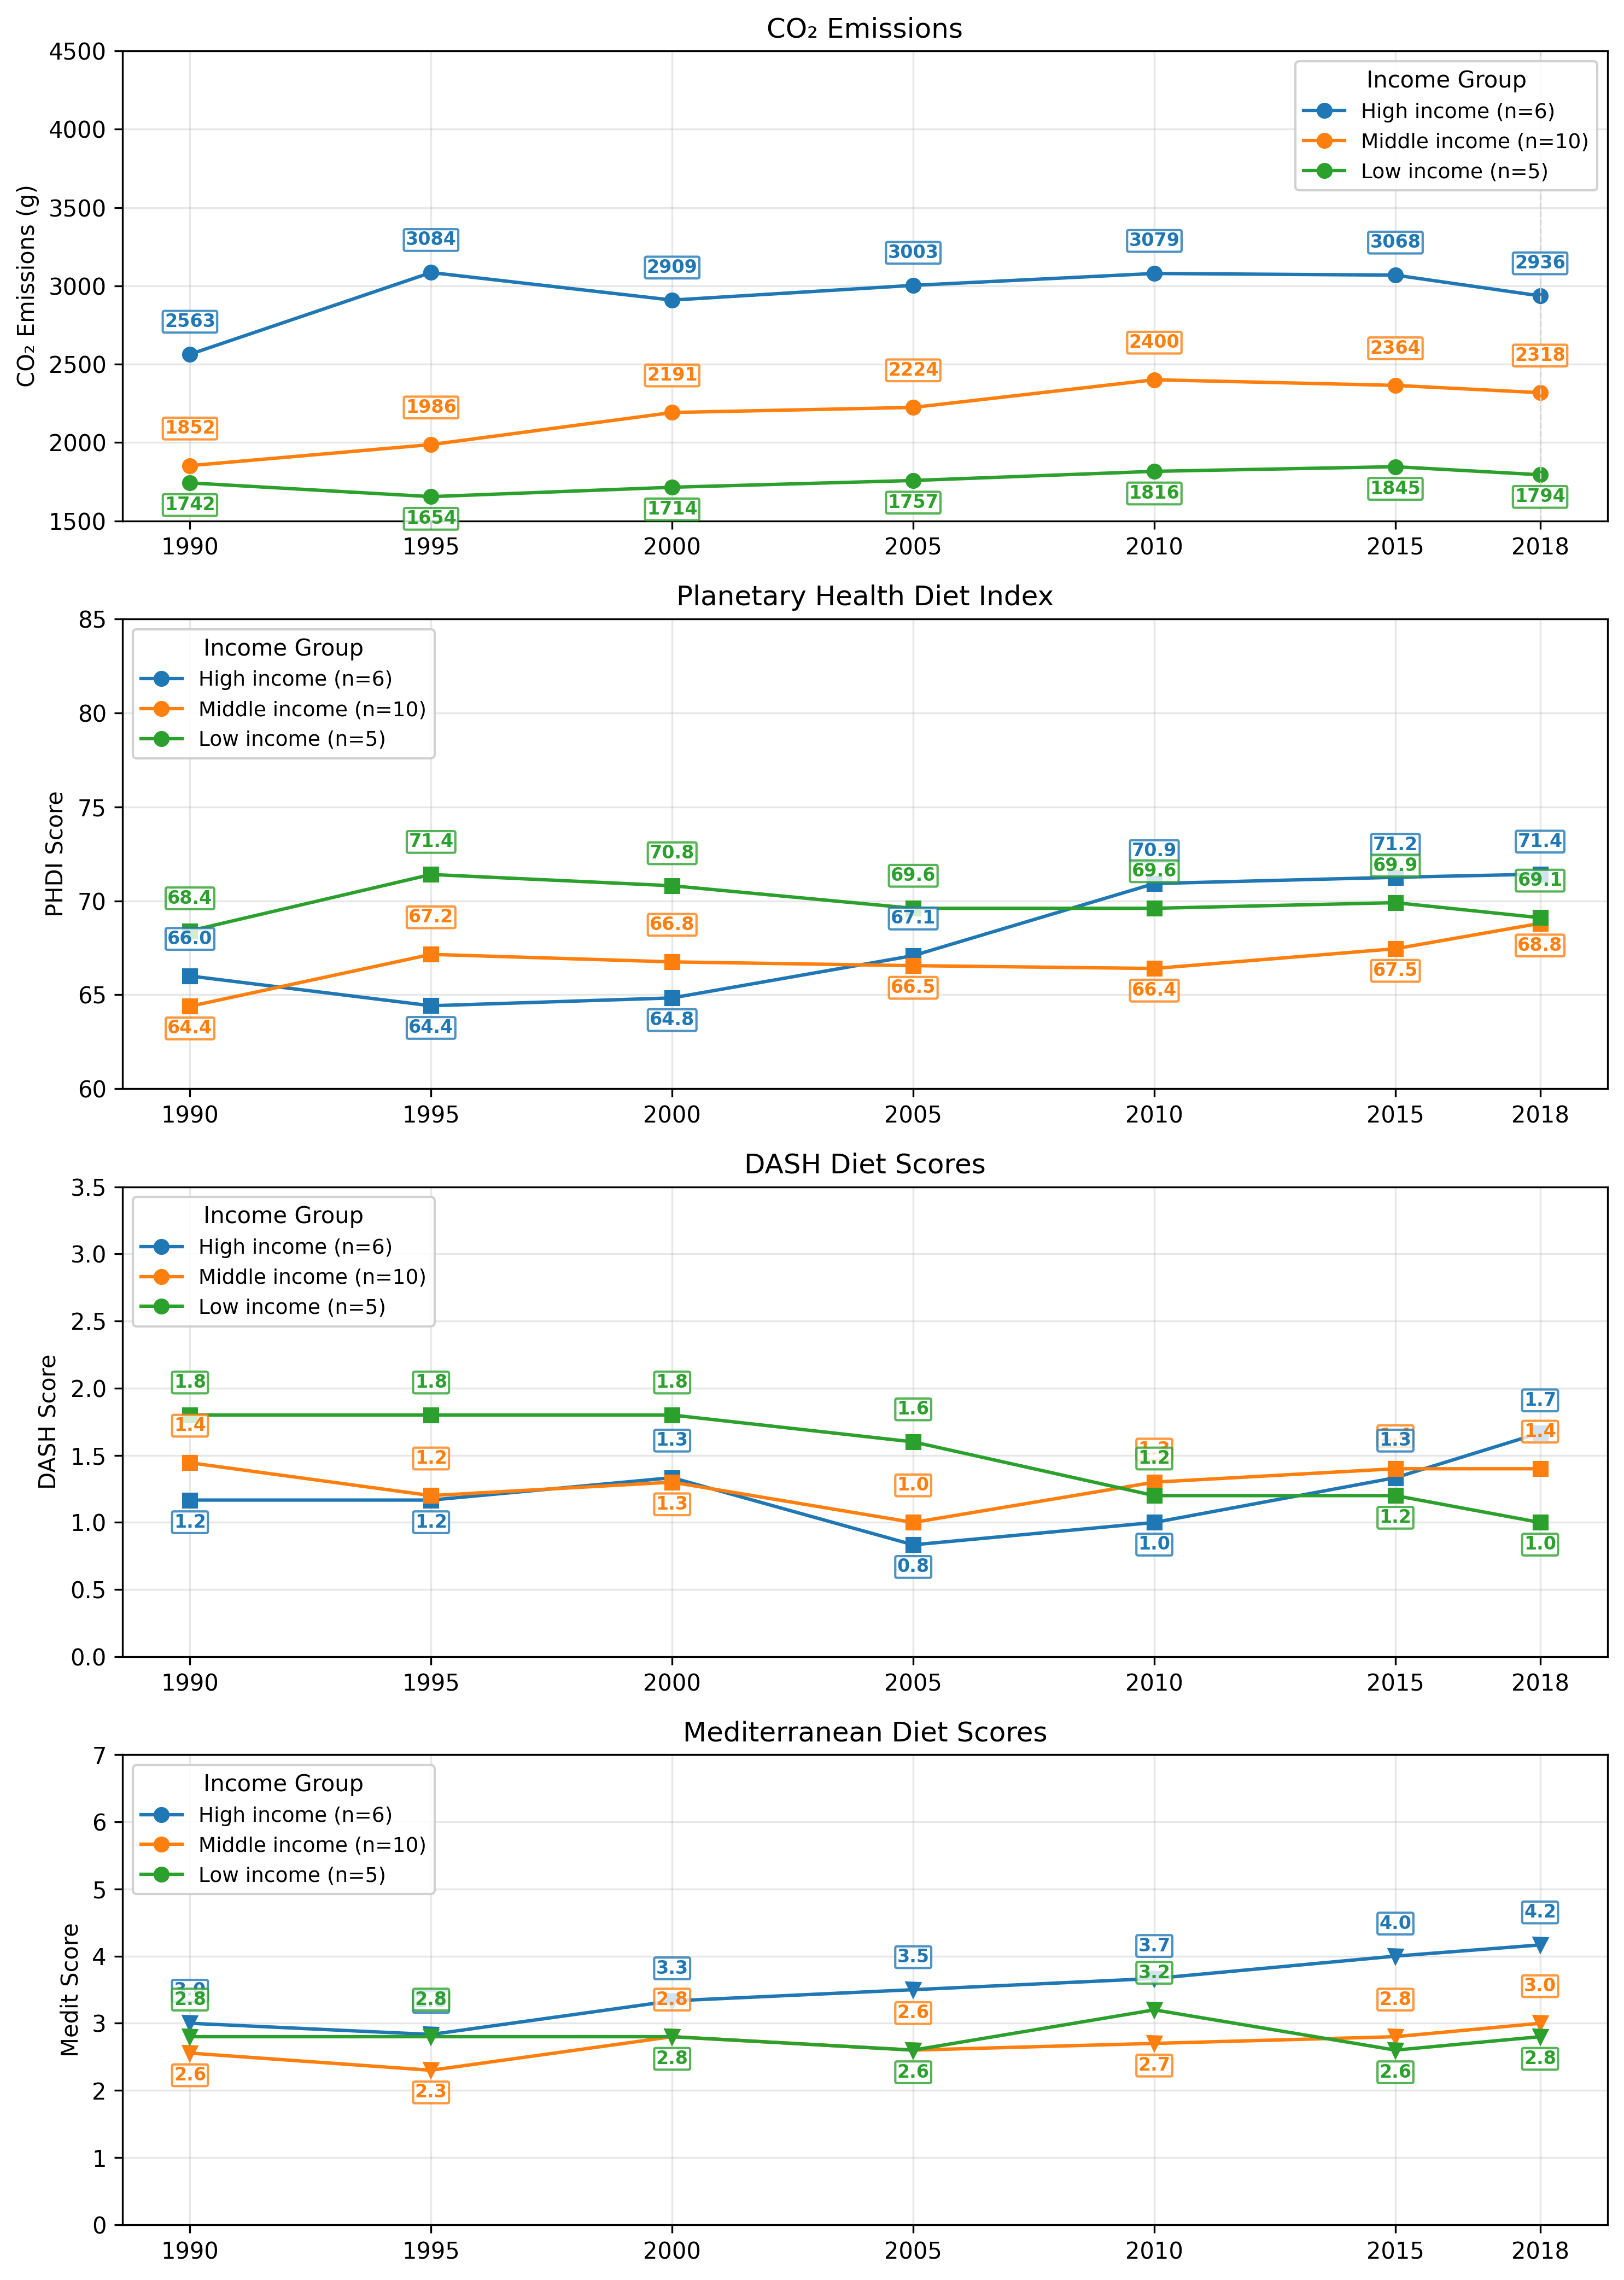

In [4]:
plot_shaded_four_panel(
    df_co2=df_co2,   # Must have: income_group, year, emissions
    df_phdi=df_phdi, # Must have: income_group, 2010, 2015...
    df_dash=df_dash, # Must have: income_group, 2010, 2015...
    df_medit=df_medit, # Must have: income_group, 2010, 2015...
    n_years=7
)

In [6]:
import os
import numpy as np
import pandas as pd
from scipy import stats
from typing import List, Dict, Tuple, Optional

# Desired order of income groups
INCOME_ORDER = ["High income", "Middle income", "Low income"]


def _order_income_groups(groups: set) -> List[str]:
    groups = [g for g in groups if pd.notna(g)]
    ordered = [g for g in INCOME_ORDER if g in groups]
    rest = sorted([g for g in groups if g not in INCOME_ORDER], key=lambda x: str(x))
    return ordered + rest


def _compare_groups(groups_data: List[np.ndarray]) -> Tuple[Optional[str], Optional[float]]:
    """
    Compare means across income groups at a single time point.
    Returns (test_name, p_value).
    Uses one-way ANOVA if possible; otherwise falls back to Kruskal-Wallis.
    """
    valid = [g for g in groups_data if len(g) > 0]
    if len(valid) < 2:
        return None, None

    # ANOVA requires at least 2 observations per group and non-zero variance
    can_anova = all(len(g) >= 2 and np.var(g) > 0 for g in valid)
    if can_anova:
        try:
            _, p = stats.f_oneway(*valid)
            return "ANOVA", p
        except Exception:
            pass

    # Fallback to Kruskal-Wallis
    try:
        _, p = stats.kruskal(*valid)
        return "Kruskal-Wallis", p
    except Exception:
        return None, None


def generate_summary_tables(
    df_co2: pd.DataFrame,
    df_phdi: pd.DataFrame,
    df_dash: pd.DataFrame,
    df_medit: pd.DataFrame,
    n_years: int = 7,
    output_folder: str = "figures"
) -> Dict[str, pd.DataFrame]:
    """
    Generate summary tables for each dietary/emission metric.
    
    For each year and income group, the table contains:
      - mean ± SD (95% CI: lower–upper)
    Plus columns for the statistical test name and p-value.
    
    Returns dict: metric name -> DataFrame
    Saves all tables to `summary_tables.xlsx` with one sheet per metric.
    """
    all_groups = set()
    for df in [df_co2, df_phdi, df_dash, df_medit]:
        if "income_group" in df.columns:
            uniques = df["income_group"].dropna().unique()
            all_groups.update(uniques)
    sorted_groups = _order_income_groups(all_groups)

    configs = [
        (df_co2, "co2", "long"),
        (df_phdi, "phdi", "wide"),
        (df_dash, "dash", "wide"),
        (df_medit, "medit", "wide")
    ]

    summary_tables = {}

    for df, name, data_type in configs:
        if "income_group" not in df.columns:
            print(f"Warning: 'income_group' missing in {name}. Skipping.")
            continue

        # Determine years
        if data_type == "long":
            years = sorted(df["year"].unique())[:n_years]
        else:
            year_cols = [c for c in df.columns if str(c).isdigit()][:n_years]
            years = [int(c) for c in year_cols]

        rows = []

        for y in years:
            row = {"year": int(y)}
            group_values_for_test = []

            for group in sorted_groups:
                if data_type == "long":
                    values = df[(df["income_group"] == group) & (df["year"] == y)]["emissions"].dropna().values
                else:
                    col = str(y)
                    if col in df.columns:
                        values = df[df["income_group"] == group][col].dropna().values
                    else:
                        values = np.array([])

                group_values_for_test.append(values)

                if len(values) > 0:
                    mean = np.mean(values)
                    if len(values) > 1:
                        sd = np.std(values, ddof=1)          # sample SD
                        se = sd / np.sqrt(len(values))
                        ci_lo = mean - 1.96 * se
                        ci_hi = mean + 1.96 * se
                    else:
                        sd = 0.0
                        ci_lo = ci_hi = mean
                    cell = f"{mean:.2f} ± {sd:.2f} (95% CI: {ci_lo:.2f}–{ci_hi:.2f})"
                else:
                    cell = "N/A"

                row[group] = cell

            # Statistical test across income groups
            test_name, p_val = _compare_groups(group_values_for_test)
            row["Test"] = test_name if test_name else "N/A"
            row["p-value"] = p_val if p_val is not None else np.nan

            rows.append(row)

        table = pd.DataFrame(rows).set_index("year")
        # Column order: income groups first, then Test, then p-value
        cols = sorted_groups + ["Test", "p-value"]
        table = table[cols]

        summary_tables[name] = table

        # Console output
        print(f"\n===== {name.upper()} — Mean ± SD (95% CI) =====")
        print(table.to_string())

    # Save to Excel
    os.makedirs(output_folder, exist_ok=True)
    excel_path = os.path.join(output_folder, "summary_tables.xlsx")
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        for metric, tbl in summary_tables.items():
            tbl.to_excel(writer, sheet_name=metric)
    print(f"\nAll summary tables saved to {excel_path}")

    return summary_tables

In [7]:
tables = generate_summary_tables(df_co2, df_phdi, df_dash, df_medit, n_years=7, output_folder="tables")



===== CO2 — Mean ± SD (95% CI) =====
                                      High income                               Middle income                                  Low income   Test   p-value
year                                                                                                                                                      
1990  2563.14 ± 1016.06 (95% CI: 1750.12–3376.15)  1852.41 ± 515.59 (95% CI: 1515.56–2189.26)  1742.13 ± 431.43 (95% CI: 1363.96–2120.30)  ANOVA  0.108186
1995  3084.87 ± 1044.20 (95% CI: 2249.34–3920.40)  1986.81 ± 512.76 (95% CI: 1669.00–2304.62)  1654.46 ± 565.42 (95% CI: 1158.85–2150.07)  ANOVA  0.007245
2000   2909.08 ± 469.05 (95% CI: 2533.77–3284.40)  2191.40 ± 640.39 (95% CI: 1794.48–2588.32)  1714.35 ± 537.75 (95% CI: 1242.99–2185.71)  ANOVA  0.009311
2005   3003.09 ± 179.05 (95% CI: 2859.82–3146.36)  2224.02 ± 632.88 (95% CI: 1831.76–2616.29)  1757.55 ± 507.88 (95% CI: 1312.37–2202.73)  ANOVA  0.002672
2010   3079.03 ± 380.38 (95% CI: